# One Piece Character, Card Game & Show Data

The goal of this project is to build a normalized relational ETL database that links data from the One Piece Anime/Manga (characters, episodes, arcs, etc.) to the One Piece TCG. This is so that questions about how the show/characters influences the card game design and choices.

# Background Information

## One Piece Data Goals

The main goal here is to create an RDB that links characters, episode and card game data together in a well organized and effeciently queried way.

The hope is that anyone using this RDB will be able to answer questions such as:


*   How does character death status affect how often a character is selected for cards?
*   Does appearing in more episodes correlate with having more cards?
*   Why do some characters have rarer cards than others using episodes/character data?
*   Does a characters debut in the show matter for how many cards they end up with?

The end user of this RDB will most likely be a fan of the show, manga, or the trading card game, curious about how the source material shapes what makes a card or a curiousity of wanting to explore their frequency/rarity patterns for their favorite One Piece characters or cards.



## Data

### Sources (for reference):

One Piece Episodes and Characters Dataset: ([link](https://www.kaggle.com/datasets/tejadhiya/one-piece-episode-summaries-episodes-1-1130/data))

One Piece TCG Card Database - July 2025 ([link](https://www.kaggle.com/datasets/jbowski/one-piece-tcg-card-database?resource=download))

One Piece Dataset ([link](https://www.kaggle.com/datasets/mexwell/one-piece-dataset))

### Data Files

Data files are downloaded then loaded into a B2 cloud storage buckets.

### Plan to Use:

**First Dataset - One Piece Episodes and Characters Dataset** Rows & Columns: 1130 Rows, 5 Columns. Plan to Use Rows & Columns: 1130 Rows, 5 Columns

**Second Dataset - One Piece TCG Card Database - July 2025** Rows & Columns: 2960 Rows, 15 Columns. Plan to Use Rows & Columns: 2960 Rows, 13 Columns

**Third Dataset - One Piece Dataset** Rows & Columns: 1394 Rows, 57 Columns. Plan to use Rows & Columns: ~1392 Rows, 18 Columns


# Extract

In [2]:
# import modules
import pandas as pd
import numpy as np
import re
import ast
pd.__version__

'2.3.3'

## Load Raw Data

In [3]:
one_piece_tcg = pd.read_csv("data/raw/one_piece_tcg.csv")
one_piece_episodes = pd.read_csv("data/raw/one_piece_episodes.csv")
one_piece_characters = pd.read_csv("data/raw/one_piece_characters.csv")

print(one_piece_tcg.shape)
print(one_piece_episodes.shape)
print(one_piece_characters.shape)


(2960, 15)
(1130, 5)
(1394, 57)


## Explore one_piece_tcg

In [ ]:
one_piece_tcg

,card_id,card_code,card_rarity,card_type,card_image,card_art_variant,card_name,card_color,card_expansion,card_power,card_cost,card_counter,card_effect,card_trigger,card_banned
0,EB01-006-0,EB01-006,SR,Animal;Straw Hat Crew,https://en.onepiece-cardgame.com/images/cardli...,0,Tony Tony.Chopper,Red,EB01,4000.0,3.0,1000.0,[Blocker] (After your opponent declares an att...,NaN,0
1,OP01-006-1,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,1,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
2,OP01-006-2,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,2,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
3,OP01-006-3,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,3,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
4,OP01-006-0,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,0,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2955,ST13-015-2,ST13-015,SR,Supernovas;Straw Hat Crew,https://en.onepiece-cardgame.com/images/cardli...,2,Monkey.D.Luffy,Yellow,ST13,6000.0,5.0,1000.0,[Activate: Main] [Once Per Turn] This Characte...,NaN,0
2956,ST16-001-1,ST16-001,SR,FILM,https://en.onepiece-cardgame.com/images/cardli...,1,Uta,Green,ST16,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,0
2957,ST16-001-2,ST16-001,SR,FILM,https://en.onepiece-cardgame.com/images/cardli...,2,Uta,Green,ST16,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,0
2958,ST17-004-1,ST17-004,SR,The Seven Warlords of the Sea;Kuja Pirates,https://en.onepiece-cardgame.com/images/cardli...,1,Boa Hancock,Blue,ST17,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,0


In [ ]:
one_piece_tcg.head()

,card_id,card_code,card_rarity,card_type,card_image,card_art_variant,card_name,card_color,card_expansion,card_power,card_cost,card_counter,card_effect,card_trigger,card_banned
0,EB01-006-0,EB01-006,SR,Animal;Straw Hat Crew,https://en.onepiece-cardgame.com/images/cardli...,0,Tony Tony.Chopper,Red,EB01,4000.0,3.0,1000.0,[Blocker] (After your opponent declares an att...,NaN,0
1,OP01-006-1,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,1,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
2,OP01-006-2,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,2,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
3,OP01-006-3,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,3,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0
4,OP01-006-0,OP01-006,UC,Land of Wano,https://en.onepiece-cardgame.com/images/cardli...,0,Otama,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,0


In [ ]:
one_piece_tcg.isna().sum()

,0
card_id,0
card_code,0
card_rarity,0
card_type,0
card_image,0
card_art_variant,0
card_name,0
card_color,0
card_expansion,0
card_power,577


**What exploring this dataset tells me:**

This dataset is relatively clean but there is still plenty of work to do. `one_piece_tcg.isna().sum()` tells me that `card_power`, `card_cost` and `card_counter` have a solid amount of nulls but this is done for a structural reason and not a data quality one. Event and stage cards don't have any power or stats. I'm deciding to keep these columns with their nulls rather than drop them because the null itself is important information that can be used later in the dataset. The `card_trigger` has the most nulls, the trigger mechanic in the One Piece Card Game is an optional ability any card type can have. It's nulls represent that the card wasn't designed with a trigger effect. I'm deciding to keep this column as well because it is a real attribute to the cards design.

I was originally going to drop `card_image` and `card_banned` as neither is used in my four reasearch questions. There is analytical value in these columns despite what I have originally questioned about them. There is no good reason to exclude these two columns.

**What needs to be fixed later:**

*   `card_type` packs multiple factions into one semicolon seperated string (e.g `"Animal;Straw Hat Crew"`). A single cell holding multiple values can be confusing so its going to become its own table (`CARD_FACTIONS`) later in the transform section.
*   `card_name` mixes characters names with an object/event/stage names in the same column with no flag distinguishing them. For example, `Otama` appears on cards that aren't technically character cards (they are stage cards themed as a character) so some signals like "does this character have a `card_power` stat?" become not reliable. Creating a flag later in transform will be vital for finding which non-character cards are characters when confirming characters.



In [ ]:
tcg_cols = one_piece_tcg.copy(deep=True)
print(tcg_cols.shape)
tcg_cols.columns

(2960, 15)


Index(['card_id', 'card_code', 'card_rarity', 'card_type', 'card_image',
       'card_art_variant', 'card_name', 'card_color', 'card_expansion',
       'card_power', 'card_cost', 'card_counter', 'card_effect',
       'card_trigger', 'card_banned'],
      dtype='object')

## Explore one_piece_episodes

In [ ]:
one_piece_episodes

,episode,episode_name,arc,summary,character_appearances
0,1,I'm Luffy! The Man Who Will Become the Pirate ...,Romance Dawn Arc,Luffy is cast at sea in a barrel. Sailors on a...,"['Nami', 'Alvida', 'Koby', 'Heppoko', 'Peppoko..."
1,2,The Great Swordsman Appears! Pirate Hunter Ror...,Romance Dawn Arc,"Luffy and Koby arrive at Shells Town, a town w...","['Monkey D. Luffy', 'Koby', 'Roronoa Zoro', 'R..."
2,3,Morgan vs. Luffy! Who's This Mysterious Beauti...,Romance Dawn Arc,"Luffy returns the katana to Zoro, who uses the...","['Roronoa Zoro', 'Monkey D. Luffy', 'Morgan', ..."
3,4,Luffy's Past! The Red-Haired Shanks Appears,Orange Town Arc,The burglar girl's dinghy is discovered by thr...,"['Tightrope Walking Funan Bros', 'Nami', 'Monk..."
4,5,"Fear, Mysterious Power! Pirate Clown Captain B...",Orange Town Arc,"The girl introduces herself as Nami, a thief t...","['Nami', 'Superhuman Domingos', 'Pinky', 'Monk..."
...,...,...,...,...,...
1125,1126,Looming Despair! Admiral Kizaru's Depressing M...,Egghead Arc,"The previous day, Kuma climbed the Red Line an...","['Bartholomew Kuma', 'Sakazuki', 'Borsalino', ..."
1126,1127,Luffy vs. Kizaru! A Fierce Kaleidoscopic Battle,Egghead Arc,"Though Kizaru insists he must kill Vegapunk, L...","['Monkey D. Luffy', 'Borsalino', 'Nami', 'Tony..."
1127,1128,The Nightmare Strikes - Warrior God of Science...,Egghead Arc,"As the Pacifistas begin attacking the Marines,...","['Jaygarcia Saturn', 'Shaka', 'Lilith', 'Pytha..."
1128,1129,Kuma's Past - Better Off Dead in This World,Egghead Arc,Doberman orders all lower-ranking Marines to l...,"['Jaygarcia Saturn', 'Jewelry Bonney', 'Doberm..."


In [ ]:
one_piece_episodes.head()

,episode,episode_name,arc,summary,character_appearances
0,1,I'm Luffy! The Man Who Will Become the Pirate ...,Romance Dawn Arc,Luffy is cast at sea in a barrel. Sailors on a...,"['Nami', 'Alvida', 'Koby', 'Heppoko', 'Peppoko..."
1,2,The Great Swordsman Appears! Pirate Hunter Ror...,Romance Dawn Arc,"Luffy and Koby arrive at Shells Town, a town w...","['Monkey D. Luffy', 'Koby', 'Roronoa Zoro', 'R..."
2,3,Morgan vs. Luffy! Who's This Mysterious Beauti...,Romance Dawn Arc,"Luffy returns the katana to Zoro, who uses the...","['Roronoa Zoro', 'Monkey D. Luffy', 'Morgan', ..."
3,4,Luffy's Past! The Red-Haired Shanks Appears,Orange Town Arc,The burglar girl's dinghy is discovered by thr...,"['Tightrope Walking Funan Bros', 'Nami', 'Monk..."
4,5,"Fear, Mysterious Power! Pirate Clown Captain B...",Orange Town Arc,"The girl introduces herself as Nami, a thief t...","['Nami', 'Superhuman Domingos', 'Pinky', 'Monk..."


In [ ]:
one_piece_episodes.isna().sum()

,0
episode,0
episode_name,0
arc,0
summary,0
character_appearances,0


**What exploring this dataset tells me:**

There are zero nulls anywhere, one row per episode and no questions about what each row represents. This is by far the easiest and cleanest dataset I will be working with. The only issue with this dataset is `character_appearances`, which is stored as a python list in a single string cell (e.g `"['Nami', 'Alvida', 'Koby', 'Heppoko', 'Peppoko', 'Poppoko', 'Monkey D. Luffy', 'Roronoa Zoro']"`). This makes it difficult to run queries and to normalize this creating its own table with one row per episode (episode, character) pair before it's usable.

I'm keeping all 5 columns and there is no column I'd cut sense all of the columns map directly into my planned final schema.

In [ ]:
episodes_cols = one_piece_episodes.copy(deep=True)
print(episodes_cols.shape)
episodes_cols["character_appearances"].iloc[0]

(1130, 5)


"['Nami', 'Alvida', 'Koby', 'Heppoko', 'Peppoko', 'Poppoko', 'Monkey D. Luffy', 'Roronoa Zoro']"

## Explore one_piece_characters

In [ ]:
one_piece_characters

,Unnamed: 0,Japanese Name,Romanized Name,Official English Name,Debut,Affiliations,Occupations,Status,Birthday,Unnamed: 9,...,Weight,Fruit Debut,Usage Debut,Previous User,key,Vessel,Homeland,Completion Date,Length,Affiliates
0,0,A・O（アー・オー）,Ā Ō,A.O. (VIZ Media and FUNimation subs);A.O (FUNi...,Chapter 551; Episode 460,A O Pirates; Subordinate of the Whitebeard Pir...,Pirate; Captain,Unknown,January 15th,Mark Fickert,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ビザール,Bizāru,Bizarre,Chapter 553; Episode 468,Subordinate of the Whitebeard Pirates,Pirate; Captain,Alive,February 3rd,Wilbur Penn,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ビヨ,Biyo,Beeyo (Viz);Biyo (Funimation subs),Chapter 658; Episode 583,NaN,NaN,Alive,NaN,Kate Oxley,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,ビシャ門,Bishamon,Bishamon,Chapter 931; Episode 925,Beasts Pirates; Orochi Oniwabanshu (former); K...,Ninja; Pirate,Alive,August 1st,Stephen Miller,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BB（ブラックバック）,Bībī (Burakkubakku),BB (Blackback)BB (Black Back) (WT100),Chapter 805; Episode 754,Mokomo Dukedom; Guardians;,Guardian,Alive,NaN,Anthony Bowling,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,1389,アゴトギ,Agotogi,Agotogi,Chapter 163; Episode 100,His own bandit gang,Bandit,Alive,NaN,Takeshi Kusao,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1390,1390,アキリア,Akiria,Agilia; Acilia,Chapter 706; Episode 654,Corrida Colosseum,Gladiator,Alive,NaN,Wendy Powell,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1391,1391,Suke Suke no Mi,Abusaromu,Absalom,Chapter 444; Episode 339,Thriller Bark Pirates (Mysterious Four) (former),ReporterSoldier Zombie and General Zombie Leader,Deceased,December 30th,Andrew Chandler,...,300 kg (661 lb),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1392,1392,アブドーラ,Abudōra,Abdullah,Chapter 704; Episode 633,Ideo Pirates; Straw Hat Grand Fleet,"Pirate, Criminal; Bounty Hunter (former)",Alive,NaN,Sean O'Connor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
one_piece_characters.head()

,Unnamed: 0,Japanese Name,Romanized Name,Official English Name,Debut,Affiliations,Occupations,Status,Birthday,Unnamed: 9,...,Weight,Fruit Debut,Usage Debut,Previous User,key,Vessel,Homeland,Completion Date,Length,Affiliates
0,0,A・O（アー・オー）,Ā Ō,A.O. (VIZ Media and FUNimation subs);A.O (FUNi...,Chapter 551; Episode 460,A O Pirates; Subordinate of the Whitebeard Pir...,Pirate; Captain,Unknown,January 15th,Mark Fickert,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ビザール,Bizāru,Bizarre,Chapter 553; Episode 468,Subordinate of the Whitebeard Pirates,Pirate; Captain,Alive,February 3rd,Wilbur Penn,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ビヨ,Biyo,Beeyo (Viz);Biyo (Funimation subs),Chapter 658; Episode 583,NaN,NaN,Alive,NaN,Kate Oxley,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,ビシャ門,Bishamon,Bishamon,Chapter 931; Episode 925,Beasts Pirates; Orochi Oniwabanshu (former); K...,Ninja; Pirate,Alive,August 1st,Stephen Miller,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BB（ブラックバック）,Bībī (Burakkubakku),BB (Blackback)BB (Black Back) (WT100),Chapter 805; Episode 754,Mokomo Dukedom; Guardians;,Guardian,Alive,NaN,Anthony Bowling,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
one_piece_characters.isna().sum()

,0
Unnamed: 0,0
Japanese Name,2
Romanized Name,3
Official English Name,107
Debut,50
Affiliations,239
Occupations,235
Status,41
Birthday,706
Unnamed: 9,343


**What exploring this dataset tells me:**

This is by far the messiest of the three sources. There are 57 columns and most of it isn't actually "characters" at all. It's just a raw dump of wifi infoboxes, and One Piece's wiki has infobox templates for characters, organizations (like pirate crews & goverments), and ships which are all scraped into the same table. Step one isn't cleaning columns, it's figuring out which rows are characters.



In [ ]:
one_piece_characters.count().sort_values(ascending=False)

,0
Unnamed: 0,1394
Character,1394
Japanese Name,1392
Romanized Name,1391
Status,1353
Debut,1344
Official English Name,1287
Occupations,1159
Affiliations,1155
Unnamed: 9,1051


**How I'm deciding what is a character vs. a organization/ship:**

In the above code block, I've sorted every column by how many non-null values it has. Columns such as `Character`, `Japanese Name`, `Romanized Name`, `Status`, `Debut` and `Offical English Name` are populating a majority of rows (1,287 - 1394 out of 1394). Columns like `Kingdom`, `Boss`, `Vessel`, and `Homeland` have only 1-15 non-null values total. The huge gap between non-null values is clear and is how I plan to decide if those infobox fields only apply to organizations and ships. Only a handful of rows are organizations/ships and not characters.

**Descriptive fields I'm planning on using:**

I plan on using `Debut`, `Origin`, `Residence`, `Affiliations`, `Status`, `Birthday`, `Meaning`, `Age at Death`, `Live Action Portrayal`, `Height`, `Blood Type`, `English Name` and `Type` (the devil fruit name/type)

I'm keeping some very sparse columns such as `Age at Death` and the devil fruit columns. Sparsity isn't what disqualifies a column but it's about how meaningful the column is to the end goal. `Age at Death` having a massive amoung of null values is what I would expect, it's not a data quality issue. The same with devil fruits, not every character has eaten a devil fruit.

The columns I'm not keeping are columns that have everything to do with organization/ship specifics such as (`Kingdom`, `Boss`, `Vessel`, `Homeland`, `Patriarch`, `Captain`, etc.). These are out of scope and they would be ~100% null within the tables by construction, not because the data would be missing. Other excluded columns are `VA` columns as they are missing a lot of data and have sparse information that isn't relevant to the database. `Weigth`, `Birth Name`, and `Features` are also incredibly sparse and have a lot of missing data so they have been dropped.

`Total Bounty` has also been dropped because while it is incredibly sparse (only 15 rows) it could be cleaned but the data would not end up accurate and only estimates.

In [ ]:
char_rows = one_piece_characters[one_piece_characters['Character'].notna() & one_piece_characters['Japanese Name'].notna()].copy()
print(f"Kept {len(char_rows)} of {len(one_piece_characters)}  rows of characters.")

keep_cols = ['Character', 'Japanese Name', 'Romanized Name', 'Official English Name', 'Debut', 'Origin', 'Residence', 'Affiliations', 'Status', 'Birthday', 'Age at Death', 'Height',
             'Blood Type', 'English Name', 'Type', 'Alias', 'LiveAction Portrayal', 'Meaning']

char_rows = char_rows[keep_cols].copy()
char_rows.head()

Kept 1392 of 1394  rows of characters.


,Character,Japanese Name,Romanized Name,Official English Name,Debut,Origin,Residence,Affiliations,Status,Birthday,Age at Death,Height,Blood Type,English Name,Type,Alias,LiveAction Portrayal,Meaning
0,A O,A・O（アー・オー）,Ā Ō,A.O. (VIZ Media and FUNimation subs);A.O (FUNi...,Chapter 551; Episode 460,NaN,NaN,A O Pirates; Subordinate of the Whitebeard Pir...,Unknown,January 15th,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bizarre,ビザール,Bizāru,Bizarre,Chapter 553; Episode 468,NaN,NaN,Subordinate of the Whitebeard Pirates,Alive,February 3rd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Biyo,ビヨ,Biyo,Beeyo (Viz);Biyo (Funimation subs),Chapter 658; Episode 583,NaN,NaN,NaN,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bishamon,ビシャ門,Bishamon,Bishamon,Chapter 931; Episode 925,Wano Country,"Flower Capital, Wano Country",Beasts Pirates; Orochi Oniwabanshu (former); K...,Alive,August 1st,NaN,"182 cm (6'0"")",XF,NaN,NaN,NaN,NaN,NaN
4,Blackback,BB（ブラックバック）,Bībī (Burakkubakku),BB (Blackback)BB (Black Back) (WT100),Chapter 805; Episode 754,NaN,Zou (Whale Forest),Mokomo Dukedom; Guardians;,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Transform

## Building a canonical character name and ID

The first step is fixing the core problem which is the character name and ID problem. There are three sources, three different naming conventions and no shared ID to join them with. The fix is to invent a standardized name string and assign it a ID. Then make the tables reference the ID instead of the name.

The two sources I'm trying to match the names against are The Card Game names and the episode apperance names which are both already in english. I'm choosing to match them with `Offical English Name` first because of english. If I decided to choose `Japanese Name` or `Romanized Name` first there would have to be a translation step and that would be much more inefficient. As a fallback for characters without an official english name, `Romanized Name` will be used second as it still uses the latin-alphabet whic his closer to match. Then the raw `Character` is the last resort when both of the better options are unuseable.

In `Official English Name` the wiki lists several names in the infobox (e.g `Beeyo (Viz);Biyo (Funimation subs)`). In this project I'm taking the first semicolon seperated value because it is difficult to determine what variant is more correct or common. There is a second step to cleaning up `Official English Name` because some names still carry translator text such as `A.O. (VIZ Media and FUNimation subs)` and this would not match the plain `A.O.` that you would find referenced in a card or episode.


In [ ]:
def get_canonical(row):
  oen = row['Official English Name']
  if pd.notna(oen):
    return str(oen).split(";")[0].strip()
  if pd.notna(row["Romanized Name"]):
    return row["Romanized Name"]
  return row["Character"]

char_rows['canonical_name'] = char_rows.apply(get_canonical, axis=1)

def clean_parentheses(s):
  return re.split(r'\s*\(', s)[0].strip()

char_rows['canonical_name'] = char_rows['canonical_name'].apply(clean_parentheses)

### Fix 29 Glued Names

Throughout the rows everything mostly looks good. There is an issue and that is within `canonical_name` there are some characters who have multiple names with no seperators that use punctucation. Their names get jammed together and it looks something like this: `Dracule MihawkDiego Mihawk`. I manually skimmed through to find 31 names that looked like this. 3 were false postives which are: `McKinley`, `McGuy` and `MocDonald` which are legitmite names that happen to just match the pattern.

The other 28 are real errors and a few more examples would be: `DaltonDolton`, `SharleyShirley` and `DogstormDogupine`. The fix is to use the raw character column as it is the actual title of the characters wiki page. All of the 31 characters turn out to have a reliable non-glued together name that matched. So rather than splitting the names apart, detecting the glue names then having it fall back to `Character` when it detects it is the idea. Any similar cases such as `McKinley` and `McGuy` won't get affected by this as well which makes it really convenient.

One extra character with a special case is `Baby 5`. The characters name was glued as so `Baby 5Baby Five` so the detection logic needed to be updated to include numbers to specifically to fix her.

In [ ]:
def is_glued(s):
  return bool(re.search(r'[a-z0-9][A-Z]', str(s)))

glued_mask = char_rows['canonical_name'].apply(is_glued) & ~char_rows['Character'].apply(is_glued)

char_rows.loc[glued_mask, 'canonical_name'] = char_rows.loc[glued_mask, 'Character']
char_rows.loc[glued_mask, ['Character', 'canonical_name']]

,Character,canonical_name
23,Straw Hat Grand Fleet,Straw Hat Grand Fleet
94,Wicca,Wicca
186,Tibany,Tibany
207,Tamanegi,Tamanegi
229,Sterry,Sterry
235,Splash and Splatter,Splash and Splatter
265,Shyarly,Shyarly
270,Shiryu,Shiryu
294,Sham,Sham
354,Rosward,Rosward


To fix the non-unique character_ids or to see if it is an error I check for duplicates on `canonical_name`

In [ ]:
dupes_mask = char_rows.duplicated('canonical_name', keep=False)
unique_names = char_rows[dupes_mask].sort_values('canonical_name')
unique_names

,Character,Japanese Name,Romanized Name,Official English Name,Debut,Origin,Residence,Affiliations,Status,Birthday,Age at Death,Height,Blood Type,English Name,Type,Alias,LiveAction Portrayal,Meaning,canonical_name
992,Ganryu,眼竜（ガンリュウ）,Ganryū,Ganryu,Chapter 966; Episode 968,NaN,NaN,Roger Pirates,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ganryu
993,Ganryu,ガンリュウ,Ganryū,Ganryu,Chapter 552; Episode 461,NaN,NaN,Spade Pirates,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ganryu
923,Hanji,ハンジ,Hanji,NaN,Chapter 949; Episode 947,NaN,NaN,Ninja-Pirate-Mink-Samurai Alliance,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hanji
924,Hanji,半次,Hanji,NaN,Chapter 929; Episode 922,NaN,Wano Country (Flower Capital),NaN,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hanji
854,Ikkaku,イッカク,Ikkaku,Ikkaku,Chapter 810; Episode 757,NaN,NaN,Heart Pirates,Unknown,December 7th,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ikkaku
855,Ikkaku,一鶴,Ikkaku,NaN,Chapter 915; Episode 902,NaN,Wano Country (Bakura Town),NaN,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ikkaku
779,Kaku,カクさん,Kaku-san,Kaku,Chapter 927; Episode 919,NaN,NaN,Kyoshiro Family,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kaku
782,Kaku,"Ushi Ushi no Mi, Model: Giraffe",Kaku,Kaku,Chapter 323; Episode 230,East Blue,Guanhao (former),CP0; CP9 (former); Galley-La Company (former),Alive,August 7th,NaN,"193 cm (6'4"")",X,Ox-Ox Fruit Giraffe Model,Zoan,NaN,NaN,Giraffe,Kaku
651,Macro,マクロ,Makuro,Macro,Chapter 437 (cover),NaN,NaN,Automata,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Macro
652,Macro,マクロ,Makuro,Macro,Chapter 197 (cover); Episode 386,Grand Line (Ryugu Kingdom; Fish-Man Island),Fish-Man District (former),Macro Pirates; Sun Pirates (former),Alive,September 6th,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Macro


### Fix 5 Duplicate Names

16 rows across 8 names collided. After some research on the One Piece Wiki and looking at the dataset, between the 8 names, 5 of the characters were actaully seperate characters.


*   `Mr. 7`, `Risky Brothers` and `Minamoto` are the same character recorded twice. I left these alone as I will be merging them into one character either way
*   `Ganryu`, `Hanji`, `Ikkaku`, `Macro` and `Kaku` are actually two different characters that just happen to share the same English name. They will be seperated by what faction/occupation they are in parantheses.




In [ ]:
char_rows.loc[992, 'canonical_name'] = 'Ganryu (Roger Pirates)'
char_rows.loc[993, 'canonical_name'] = 'Ganryu (Spade Pirates)'

char_rows.loc[923, 'canonical_name'] = 'Hanji (Ninja-Pirate-Mink-Samurai ALliance)'
char_rows.loc[924, 'canonical_name'] = 'Hanji (Prisoner)'

char_rows.loc[854, 'canonical_name'] = 'Ikkaku (Heart Pirates)'
char_rows.loc[855, 'canonical_name'] = 'Ikkaku (Wano)'

char_rows.loc[779, 'canonical_name'] = 'Kaku (Kyoshiro Family)'
char_rows.loc[782, 'canonical_name'] = 'Kaku (CP0)'

char_rows.loc[651, 'canonical_name'] = 'Macro (Automata)'
char_rows.loc[652, 'canonical_name'] = 'Macro (Macro Pirates)'

Now that `canonical_name` is fully cleaned, I use `pd.factorize()` to assign a stable integer ID to each row that will now be referenced by everywhere else.

In [ ]:
char_rows['character_id'] = pd.factorize(char_rows['canonical_name'])[0].astype(int) + 1
print(f"unique character_ids:", char_rows['character_id'].nunique(), "vs rows:", len(char_rows))
char_rows[['character_id', 'canonical_name']]

unique character_ids: 1389 vs rows: 1392


,character_id,canonical_name
0,1,A.O.
1,2,Bizarre
2,3,Beeyo
3,4,Bishamon
4,5,BB
...,...,...
1389,1385,Agotogi
1390,1386,Agilia
1391,1387,Absalom
1392,1388,Abdullah


## Building CHARACTER_ALIASES

Instead of including this inside of the `CHARACTERS` table, making a different `CHARACTER_ALIASES` table is more convenient for a slew of reasons. The whole reason I picked to have one canonical name is that the other two sources won't use it consistently. Basically, `CARDS.card_name` might say `Tony.Tony.Chopper` but `character_appearances` may just say the name `Chopper`. Both of these need to resolve into the same `character_id` which means I need every different possible version of the name recorded. This is actually the same problem that will arise with the tables of `CHARACTER_EPISODES_APPEARANCES` and `CARD_FACTIONS`.

Normalizing the names will be vital as `Tony Tony.Chopper` and `Tony Tony Chopper` are completely different strings when they are obviously supposed to be the same name with slightly different spelling. Normalizing the punctuation and turning the strings to lowercase before storing is how I will fix this issue.

Gathering the variants from `canonical_name`, `Official English Name`, `Romanized Name`, `Japanese Name`, and `Alias` all together is inmportant as any of these can be what a card name or episode reference actually matches against. I'm not too sure which variant an external source may use so the alias table needs to have everything. I can't just guess.

In [ ]:
# Helper Functions

def normalize_name (name, strip_parentheses=False):
  if pd.isna(name):
    return None

  name = str(name)

  if strip_parentheses:
    name = re.sub(r'\(.*?\)', '', name)

  name = name.lower()
  name = re.sub(r'[^a-z0-9]+', ' ', name)
  name = re.sub(r'\s+', ' ', name).strip()

  return name


# Only used for CHARACTER_ALIASES
def get_name_variants(row):
  variants = set()
  variants.add(row['canonical_name'])
  variants.add(row['Character'])

  if pd.notna(row['Official English Name']):
    for name in str(row['Official English Name']).split(';'):
      variants.add(clean_parentheses(name.strip()))

  if pd.notna(row['Romanized Name']):
    variants.add(row['Romanized Name'])

  if pd.notna(row['Japanese Name']):
    variants.add(row['Japanese Name'])

  if pd.notna(row['Alias']):
    for name in str(row['Alias']).split(';'):
      variants.add(name.strip())

  return variants

In [ ]:
alias_rows = []

for _, row in char_rows.iterrows():
  character_id = row['character_id']
  name_variants = get_name_variants(row)

  for name in name_variants:
    normalized_name = normalize_name(name)
    if normalized_name:
      alias_rows.append({
          'character_id': character_id,
          'alias_text': name,
          'norm_alias': normalized_name,
          'source_dataset': 'onepiece_wiki'
      })

character_aliases = pd.DataFrame(alias_rows)
character_aliases = character_aliases.drop_duplicates(subset = ['character_id', 'norm_alias'])
character_aliases['alias_id'] = character_aliases.index + 1

# lookup dict for matching cards/episodes later

alias_lookup = {}
for _, row in character_aliases.iterrows():
  normalized_name = row['norm_alias']
  if normalized_name not in alias_lookup:
    alias_lookup[normalized_name] = row['character_id']

character_aliases

,character_id,alias_text,norm_alias,source_dataset,alias_id
0,1,A.O.,a o,onepiece_wiki,1
4,2,Bizarre,bizarre,onepiece_wiki,5
5,2,Bizāru,biz ru,onepiece_wiki,6
6,3,Beeyo,beeyo,onepiece_wiki,7
7,3,Biyo,biyo,onepiece_wiki,8
...,...,...,...,...,...
3110,1388,Abudōra,abud ra,onepiece_wiki,3111
3111,1388,Abdullah,abdullah,onepiece_wiki,3112
3112,1389,Aderu,aderu,onepiece_wiki,3113
3113,1389,Adele,adele,onepiece_wiki,3114


## Building ARCS

I decided to inlcude `arcs` into its own table instead of staying a column on `EPISODES`. It's a repeated value so dozens of episodes share the same arc name. Pulling it to its own table gives a place to attach `arc_order` which currently doesn't exist anywhere in the source data.

To create `arc_order` using episodes seemed like a possible way to derive the order. Using the minimum episode as they are already aired in order, the earliest episode of the arc name is a way to order it.

In [ ]:
episode_and_arc = (episodes_cols[['arc', 'episode']])
first_episode_per_arc = episode_and_arc.groupby('arc', as_index=False)['episode'].min()
first_episode_per_arc = first_episode_per_arc.rename(columns={'episode': 'first_episode'})

first_episode_per_arc = first_episode_per_arc.sort_values('first_episode')
first_episode_per_arc = first_episode_per_arc.reset_index(drop=True)

arcs_raw = first_episode_per_arc
arcs_raw['arc_id'] = arcs_raw.index + 1
arcs_raw['arc_order'] = arcs_raw.index + 1

arcs = arcs_raw.rename(columns={'arc': 'arc_name'})
arcs = arcs[['arc_id', 'arc_name', 'arc_order']]

arcs

,arc_id,arc_name,arc_order
0,1,Romance Dawn Arc,1
1,2,Orange Town Arc,2
2,3,Syrup Village Arc,3
3,4,Baratie Arc,4
4,5,Arlong Park Arc,5
...,...,...,...
60,61,Cidre Guild Arc,61
61,62,One Piece Anime 20th Anniversary Special Roman...,62
62,63,Uta’s Past,63
63,64,Time to Depart – Wano Country and the Straw Hats,64


## Building EPISODES

Building episodes will be more straightforward and will just join episode data with `arc_id`

In [ ]:
episode_columns = episodes_cols[['episode', 'episode_name', 'arc', 'summary']]

episodes_with_arc_id = episode_columns.merge(
    arcs[['arc_id', 'arc_name']], left_on='arc', right_on='arc_name', how='left'
)

episodes_with_arc_id = episodes_with_arc_id.rename(columns={'episode': 'episode_id'})

episodes = episodes_with_arc_id[['episode_id', 'episode_name', 'arc_id', 'summary']]

episodes

,episode_id,episode_name,arc_id,summary
0,1,I'm Luffy! The Man Who Will Become the Pirate ...,1,Luffy is cast at sea in a barrel. Sailors on a...
1,2,The Great Swordsman Appears! Pirate Hunter Ror...,1,"Luffy and Koby arrive at Shells Town, a town w..."
2,3,Morgan vs. Luffy! Who's This Mysterious Beauti...,1,"Luffy returns the katana to Zoro, who uses the..."
3,4,Luffy's Past! The Red-Haired Shanks Appears,2,The burglar girl's dinghy is discovered by thr...
4,5,"Fear, Mysterious Power! Pirate Clown Captain B...",2,"The girl introduces herself as Nami, a thief t..."
...,...,...,...,...
1125,1126,Looming Despair! Admiral Kizaru's Depressing M...,65,"The previous day, Kuma climbed the Red Line an..."
1126,1127,Luffy vs. Kizaru! A Fierce Kaleidoscopic Battle,65,"Though Kizaru insists he must kill Vegapunk, L..."
1127,1128,The Nightmare Strikes - Warrior God of Science...,65,"As the Pacifistas begin attacking the Marines,..."
1128,1129,Kuma's Past - Better Off Dead in This World,65,Doberman orders all lower-ranking Marines to l...


## Building CHARACTER_EPISODE_APPEARANCES

I believe that creating this table instead of leaving it in its python list format will have plenty of benefits. It will result in clearer more normalized data while having one row per (episode, character) pair with `apperance_order` preserved. Without creating this table questions such as "how many episodes as this character appeared in" or "who showed up earliest in this episode" cannot be answered.

In [ ]:
appearance_rows = []
unmatched_appearance_names = set()

for _, row in episodes_cols.iterrows():
  try:
    character_names = ast.literal_eval(row['character_appearances'])
  except Exception:
    character_name = []

  for appearance_order, character_name in enumerate(character_names, start=1):
    normalized_name = normalize_name(character_name)
    character_id = alias_lookup.get(normalized_name)

    if character_id is None:
      unmatched_appearance_names.add(character_name)
      continue

    appearance_rows.append({
          'episode_id': row['episode'],
          'character_id': character_id,
          'appearance_order': appearance_order
      })

print(f"{len(appearance_rows)} appearances matched, {len(unmatched_appearance_names)} unique names not matched")

26923 appearances matched, 482 unique names not matched


### Fix 43 Unmatched Names

It looks like 26923 appearances matched while 482 unique names are unmatched. Rather than recovering every unmatched name as a new minor character I've created a list and decided case by case. Here are the two passes in order:


1.   Manually verify - for the remaining names appearing in 5+ episodes, I checked each one indiviually against the raw wiki data. These characters that are important chracters can have a one letter misspelling (e.g `Iceburg` & `Iceberg`) or in a few cases just be a alias that was missing from an exisiting aliases such as `Whitebeard`, `Brownbeard` and `Niwatori`. These get added as new rows in `CHARACTER_ALIASES` then get pointed to their real, existing `character_id`.
2.   Everyone else dropped - as I have manually gone through every character in the 5 - 15+ appearances range. Any other characters without a higher frequency gets dropped. This is deliberate and goes against trying to keep everyone but I believe that checking the alternative (accidently duplicating major characters such as Kaido or Luffy) was a worse outcome than dropping minor mentions.

Going through 482 remaining unique names by hand isn't practical and most of the do not matter. What matters is the frequency they appear in the show. So, counting how much episodes the unmatched names appear in, and by hand verify any names that have 15+ episodes.



In [ ]:
from collections import Counter

mention_counts = Counter()
for _, row in episodes_cols.iterrows():
    try:
        character_names = ast.literal_eval(row['character_appearances'])
    except Exception:
        character_names = []
    for character_name in character_names:
        if character_name in unmatched_appearance_names:
            mention_counts[character_name] += 1

high_freq_unmatched = sorted(
    [(name, count) for name, count in mention_counts.items() if count >= 5],
    key=lambda pair: -pair[1]
)

print(f"{len(high_freq_unmatched)} unmatched names")
for name, count in high_freq_unmatched:
    print(f"  {name!r}: {count} episodes")

120 unmatched names
  'Trafalgar Law': 95 episodes
  'Kanjuro': 95 episodes
  'Hyougoro': 94 episodes
  'Mozu': 54 episodes
  'Kiwi': 54 episodes
  'Sogeking': 52 episodes
  'Kizaru': 50 episodes
  'Aokiji': 49 episodes
  'Akainu': 42 episodes
  'Momonosuke': 40 episodes
  'Whitebeard': 35 episodes
  'Brownbeard': 32 episodes
  'Thunder Soldier': 30 episodes
  'Guernika': 26 episodes
  'Tenguyama Hitetsu': 24 episodes
  'O-Kiku': 24 episodes
  'Niwatori': 20 episodes
  'Dago': 19 episodes
  'Footbianco': 19 episodes
  'Nyon': 19 episodes
  'Ottoland': 17 episodes
  'Ammo Knights': 16 episodes
  'Komurasaki': 16 episodes
  'Mr. 2 Bon Kurei': 15 episodes
  'Ryuma': 15 episodes
  'Mr. 3': 14 episodes
  'Mr. 1': 14 episodes
  'Miss Doublefinger': 14 episodes
  'Kyoshiro': 14 episodes
  'Kuina': 13 episodes
  'Violet': 13 episodes
  'Jonathan': 12 episodes
  'Don Krieg': 11 episodes
  'Mr. 4': 11 episodes
  'Miss Merry Christmas': 11 episodes
  'Bon Kurei': 11 episodes
  'Mr. 5': 10 episode

In [ ]:
manual_matches = {

    # 15+ Episode Threshold 'Ammo Knights' purposfully excluded as is not a character

    'Trafalgar Law': 169,          # Trafalgar D. Water Law
    'Hyougoro': 865,               # Hyogoro
    'Guernika': 941,               # Guernica
    'Sogeking': 136,               # Alternate Persona of Usopp
    'Kizaru': 1292,                # Borsalino
    'Aokiji': 686,                 # Kuzan
    'Akainu': 337,                 # Sakazuki
    'Mr. 2 Bon Kurei': 15,         # Bentham
    'Komurasaki': 712,             # Kozuki Hiyori
    'O-Kiku': 747,                 # Kikunojo
    'Thunder Soldier': 683,        # Kyros
    'Nyon': 960,                   # Gloriosa
    'Whitebeard': 1052,            # Edward Newgate
    'Brownbeard': 1244,            # Chadros Higelyges
    'Tenguyama Hitetsu': 708,      # Kozuki Sukiyaki
    'Niwatori': 206,               # Tamago
    'Dago': 39,                    # Kairiki Destroyers -- shared with the two below
    'Footbianco': 39,              # Kairiki Destroyers
    'Ottoland': 39,                # Kairiki Destroyers
    'Ryuma': 292,                  # Shimotsuki Ryuma
    'Kiwi': 732,                   # Mozu & Kiwi -- shared with below
    'Mozu': 732,                   # Mozu & Kiwi
    'Momonosuke': 710,             # Kozuki Momonosuke

    # < 15 Episode Threshold

    'Mr. 3': 996,                  # Galdino
    'Mr. 1': 1102,                 # Daz Bonez
    'Miss Doublefinger': 65,       # Zala
    'Kyoshiro': 1095,              # Denjiro
    'Violet': 114,                 # Viola
    'Don Krieg': 707,              # Kreig
    'Mr. 4': 1341,                 # Babe
    'Miss Merry Christmas': 1058,  # Drophy
    'Bon Kurei': 15,               # Bentham -- same character as 'Mr. 2 Bon Kurei' above
    'Mr. 5': 983,                  # Gem
    'Miss Valentine': 601,         # Mikita
    'Miss All Sunday': 495,        # Nico Robin
    'Miss Goldenweek': 629,        # Marianne
    'Ryokugyu': 1359,              # Aramaki
    'Lola (Zombie)': 1196,         # Charlotte Lola
    'Kuina': 283,                  # Shimotsuki Kuina
    'Basil': 1324,                 # Basil Hawkins
    'Drake': 93,                   # X. Drake
    'Shepherd': 281,                # St. Shepherd Ju Peter
    'Mobile': 1189,                # Charlotte Mobile

}

new_manual_aliases = []
for name, character_id in manual_matches.items():
  normalized_name = normalize_name(name)
  alias_lookup[normalized_name] = character_id
  new_manual_aliases.append({
      'character_id': character_id,
      'alias_text': name,
      'norm_alias': normalized_name,
      'source_dataset': 'manually_verified'
  })
  unmatched_appearance_names.discard(name)

character_aliases = pd.concat([character_aliases, pd.DataFrame(new_manual_aliases)], ignore_index=True)
character_aliases['alias_id'] = character_aliases.index + 1

print("Manually matched", len(manual_matches))
print("Remaining unmatched, dropped", len(unmatched_appearance_names))

Manually matched 43
Remaining unmatched, dropped 439


Now that the appearances table has been extended and each of the manually verified characters have been verified its time to rebuild the appearance table. As mentioned before, any name that still doesn't have no character_id now gets dropped.

In [ ]:
appearance_rows = []
dropped_mentions = 0

for _, row in episodes_cols.iterrows():
  try:
    character_names = ast.literal_eval(row['character_appearances'])
  except Exception:
    character_name = []

  for appearance_order, character_name in enumerate(character_names, start=1):
    character_id = alias_lookup.get(normalize_name(character_name))
    if character_id is None:
      dropped_mentions += 1
      continue
    appearance_rows.append({
          'episode_id': row['episode'],
          'character_id': character_id,
          'appearance_order': appearance_order
      })

character_episode_appearances = pd.DataFrame(appearance_rows)
character_episode_appearances['appearance_id'] = character_episode_appearances.index + 1
character_episode_appearances = character_episode_appearances[['appearance_id', 'episode_id', 'character_id', 'appearance_order']]

print("character_episode_appearances rows", len(character_episode_appearances))
print("dropped_mentions", dropped_mentions)

character_episode_appearances rows 27975
dropped_mentions 1246


## Building CHARACTERS

There is a lot to work on with building and finalizing the `CHARACTERS` table. This includes the `Debut`, `Age at Death`, `Height` and `devil_fruit` columns.

Lets talk about the `Debut` column first. The `Debut` column isn't a clean column as it has the manga chapter and the episode mixed into one text field (e.g `Chapter 551; Episode 460` ). I've decided to parse `Debut` into two columns, `debut_episode_id` and `debut_manga_id`.

`debut_episode_id` is able to reference off of `episode_id` in the `EPISODES` table. This can make quering data from both tables easier and more efficent. To make sure any queries don't fail, checking whether the exact number exists within the `episode_id` in the real `EPISODES` table is a good idea. If it does then keep it, if it doesn't then store it as a `NULL` instead.

With `debut_manga_id` there is no `CHAPTERS` or `MANGA` table anywhere in this schema so unlike `debut_episode_id` which has to validate against real rows in `EPISODES`, `debut_manga_id` is actually just a plain interger with no rteal reference. It is "id" in name only. I decided to keep the manga as it is real information that would be a waste to discard.

In [ ]:
def split_debut_episode(debut_text):
  if pd.isna(debut_text):
    return np.nan
  match = re.search(r'Episode\s+(\d+)', str(debut_text))
  return int(match.group(1)) if match else np.nan

char_rows['debut_episodes_id'] = char_rows['Debut'].apply(split_debut_episode)

valid_episode_ids = set(episodes['episode_id'])
char_rows.loc[~char_rows['debut_episodes_id'].isin(valid_episode_ids), 'debut_episodes_id'] = np.nan

print("resolved debut_episode_id", char_rows['debut_episodes_id'].notna().sum(), "/", len(char_rows))

def split_debut_manga(debut_text):
  if pd.isna(debut_text):
    return np.nan
  match = re.search(r'Chapter\s+(\d+)', str(debut_text))
  return int(match.group(1)) if match else np.nan

char_rows['debut_manga_id'] = char_rows['Debut'].apply(split_debut_manga)

print("resolved debut_manga_id", char_rows['debut_manga_id'].notna().sum(), "/", len(char_rows))

resolved debut_episode_id 1231 / 1392
resolved debut_manga_id 1318 / 1392


When it comes to `Age at Death` and `Height` they each have a similar problem.

`Age at Death` has values such as `32 (82 from spent lifespan)` and height has values such as `182cm (6'0\)` and even lengths that are in miles and kilometers that only apply to ships that have been mixed into the characters row.

With `Height` filtering to only values that are measured in cm before getting a wrong unit number can make data flaunt off the wrong height. Naming the column to `height_cm` makes the unit more clear as well.

In [ ]:
def first_int(text):
  if pd.isna(text):
    return np.nan
  match = re.search(r'\d{1,3}(?:,\d{3})+|\d+', str(text))
  if not match:
    return np.nan
  return int(match.group(0).replace(',', ''))

char_rows['age_at_death'] = char_rows['Age at Death'].apply(first_int)

height_is_cm = char_rows['Height'].astype(str).str.contains(r'^\d+\s*cm', regex=True, na=False)
char_rows['height_cm'] = char_rows['Height'].where(height_is_cm).apply(first_int)

print("resolved age at death:", char_rows['age_at_death'].notna().sum())
print("resolved height_cm:", char_rows['height_cm'].notna().sum())

resolved age at death: 36
resolved height_cm: 379


Last to fix in `CHARACTERS` is the devil fruit columns. The source column, `English Name` has a similar problem encountered previously.

Just like how `Offical English Name` had multiple issues like glued together names and multiple different values like `Beeyo (Viz);Biyo (Funimation subs)`. `English Name` has the same issue. An example would be: `Boing Boing Fruit (VIZ); Spring-Spring Fruit (Funimation)`.

Sense this is the same problem it can be fixed by the same solution. While with `devil_fruit_type` there is no cleanup needed as its values are consistant and labeled properly.

In [ ]:
def clean_devil_fruit(text):
  if pd.isna(text):
    return np.nan
  first_variant = str(text).split(';')[0].split(',')[0].strip()
  return clean_parentheses(first_variant) if first_variant else np.nan

char_rows['devil_fruit'] = char_rows['English Name'].apply(clean_devil_fruit)
char_rows['devil_fruit_type'] = char_rows['Type']
print("devil fruit fixed:", char_rows['devil_fruit'].notna().sum())

devil fruit fixed: 179


Time to create the final charaters table.

In [ ]:
characters_final = char_rows[[
    'character_id',
    'canonical_name',
    'Japanese Name',
    'Romanized Name',
    'Official English Name',
    'Origin',
    'Residence',
    'debut_episodes_id',
    'debut_manga_id',
    'Affiliations',
    'Status',
    'age_at_death',
    'height_cm',
    'Blood Type',
    'devil_fruit',
    'devil_fruit_type',
    'Birthday',
    'LiveAction Portrayal',
    'Meaning'
]].rename(columns={
    'Japanese Name': 'japanese_name',
    'Romanized Name': 'romanized_name',
    'Official English Name': 'official_english_name',
    'Origin': 'origin',
    'Residence': 'residence',
    'Affiliations': 'affiliations',
    'Status': 'status',
    'Blood Type': 'blood_type',
    'Birthday': 'birthday',
    'LiveAction Portrayal': 'liveaction_portrayal',
    'Meaning': 'name_meaning'
}).drop_duplicates(subset='character_id').reset_index(drop=True)

print("final characters:", characters_final.shape)
characters_final

final characters: (1389, 19)


,character_id,canonical_name,japanese_name,romanized_name,official_english_name,origin,residence,debut_episodes_id,debut_manga_id,affiliations,status,age_at_death,height_cm,blood_type,devil_fruit,devil_fruit_type,birthday,liveaction_portrayal,name_meaning
0,1,A.O.,A・O（アー・オー）,Ā Ō,A.O. (VIZ Media and FUNimation subs);A.O (FUNi...,NaN,NaN,460.0,551.0,A O Pirates; Subordinate of the Whitebeard Pir...,Unknown,NaN,NaN,NaN,NaN,NaN,January 15th,NaN,NaN
1,2,Bizarre,ビザール,Bizāru,Bizarre,NaN,NaN,468.0,553.0,Subordinate of the Whitebeard Pirates,Alive,NaN,NaN,NaN,NaN,NaN,February 3rd,NaN,NaN
2,3,Beeyo,ビヨ,Biyo,Beeyo (Viz);Biyo (Funimation subs),NaN,NaN,583.0,658.0,NaN,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Bishamon,ビシャ門,Bishamon,Bishamon,Wano Country,"Flower Capital, Wano Country",925.0,931.0,Beasts Pirates; Orochi Oniwabanshu (former); K...,Alive,NaN,182.0,XF,NaN,NaN,August 1st,NaN,NaN
4,5,BB,BB（ブラックバック）,Bībī (Burakkubakku),BB (Blackback)BB (Black Back) (WT100),NaN,Zou (Whale Forest),754.0,805.0,Mokomo Dukedom; Guardians;,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,1385,Agotogi,アゴトギ,Agotogi,Agotogi,NaN,Arabasta,100.0,163.0,His own bandit gang,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1385,1386,Agilia,アキリア,Akiria,Agilia; Acilia,NaN,NaN,654.0,706.0,Corrida Colosseum,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1386,1387,Absalom,Suke Suke no Mi,Abusaromu,Absalom,West Blue,NaN,339.0,444.0,Thriller Bark Pirates (Mysterious Four) (former),Deceased,NaN,195.0,F,Clear-Clear Fruit,Paramecia,December 30th,NaN,See-through; Sheer
1387,1388,Abdullah,アブドーラ,Abudōra,Abdullah,NaN,NaN,633.0,704.0,Ideo Pirates; Straw Hat Grand Fleet,Alive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fix 18 Only Found in Card Data Names

These characters were found in the card data that were under `is_character_card = FALSE`. A majority of these characters are either filler, movie only characters, or minor characters that ended up getting a one off card.

In [ ]:
next_character_id = characters_final['character_id'].max() + 1

cards_only_characters = [
    {'character_id': next_character_id + 0, 'canonical_name': 'Otama'},
    {'character_id': next_character_id + 1, 'canonical_name': 'Daddy Masterson'},
    {'character_id': next_character_id + 2, 'canonical_name': 'Jonathan'},
    {'character_id': next_character_id + 3, 'canonical_name': 'Douglas Bullet'},
    {'character_id': next_character_id + 4, 'canonical_name': 'Carmen'},
    {'character_id': next_character_id + 5, 'canonical_name': 'Lim'},
    {'character_id': next_character_id + 6, 'canonical_name': 'Zephyr'},
    {'character_id': next_character_id + 7, 'canonical_name': 'Bins'},
    {'character_id': next_character_id + 8, 'canonical_name': 'Musshuru'},
    {'character_id': next_character_id + 9, 'canonical_name': 'Adio'},
    {'character_id': next_character_id + 10, 'canonical_name': 'Carina'},
    {'character_id': next_character_id + 11, 'canonical_name': 'Mr. Tanaka'},
    {'character_id': next_character_id + 12, 'canonical_name': 'Baron Omatsuri'},
    {'character_id': next_character_id + 13, 'canonical_name': 'Gasparde'},
    {'character_id': next_character_id + 14, 'canonical_name': 'Shuraiya'},
    {'character_id': next_character_id + 15, 'canonical_name': 'Z'},
    {'character_id': next_character_id + 16, 'canonical_name': 'Ain'},
    {'character_id': next_character_id + 17, 'canonical_name': 'Gordon'},
]

for character in cards_only_characters:
  normalized_name = normalize_name(character['canonical_name'])
  alias_lookup[normalized_name] = character['character_id']

characters_final = pd.concat([characters_final, pd.DataFrame(cards_only_characters)], ignore_index=True)

new_card_character_alias_rows = [
  {
    'character_id': character['character_id'],
    'alias_text': character['canonical_name'],
    'norm_alias': normalize_name(character['canonical_name']),
    'source_dataset': 'cards_only'
  }
  for character in cards_only_characters
]

character_aliases = pd.concat([character_aliases, pd.DataFrame(new_card_character_alias_rows)], ignore_index=True)
character_aliases['alias_id'] = character_aliases.index + 1

print(f"Added {len(cards_only_characters)} characters into data")


Added 18 characters into data


## Matching CARDS to characters and splitting CARD_FACTIONS

The final two tables are `CARDS` and `CARD_FACTIONS`

`card_name` needs to be normalized the same way as episode names were. The function of `normalize_name()` has already been created so using the function we can normalize `card_name` of the same issue. For example, `Tony Tony.Chopper` needs to be normalized to `tony tony chopper`. The only addition will be `strip_parentheses=True` as card names have additional text in parentheses that may need to be stripped to avoid non-matches.

`card_type` will become its own table into `CARD_FACTIONS` instead of staying as a single column. For example, a `card_type` may have multiple factions like `Animal` and `Straw Hat Crew` so seperating them into different rows is the ideal option. There are questions that can only be asked by doing this for example "How many cards are in the Straw Hat Crew faction"?

### Fix 39 Card Alias Names

There are twenty six names that have a card specfic naming gap. A few examples are `Eustass"Captain"Kid` and `Capone"Gang"Bege` which both fail to match despite both characters existing in the wiki data. This is because of their middle names `Captain` and `Gang` which the wiki's alias never mentioned. There are other characters who went by an alias in other arcs such as `Lucy` for `Sabo` and `Ms. All Sunday` for `Nico Robin`.

I've added a quick fix here for the unmatched cards that include this issue.


In [ ]:
card_alias_fix = {
    'eustass captain kid': 1034,    # Eustass Kid
    'capone gang bege': 1259,       # Capone Bege
    'ms all sunday': 495,           # Nico Robin
    'gastino': 1269,                # Caesar Clown
    'zoro juurou': 357,             # Roronoa Zoro
    'luffy tarou': 558,             # Monkey D. Luffy
    'biscuit warrior': 1217,        # Charlotte Cracker
    'lucy': 343,                    # Sabo
    'okiku': 747,                   # Kikunojo
    'o nami': 515,                  # Nami
    'san gorou': 326,               # Sanji
    'chopa emon': 175,              # Tony Tony Chopper
    'o robi': 495,                  # Nico Robin
    'fra nosuke': 1015,             # Franky
    'hone kichi': 1283,             # Brook
    'captain mckinley': 606,        # McKinley
    'hitokiri kamazo': 742,         # Killer
    'alber': 738,                   # King
    'count niwatori': 206,          # Tamago
    'viscount hiyoko': 206,         # Tamago
    'baron tamago': 206,            # Tamago
    'kujyaku': 705,                 # Kujaku
    'mamboshi': 645,                # Manboshi
    'miss sarahebi': 325,           # Sarahebi
    'littleoars jr': 660,           # Little Oars Jr.
    'dr hogback': 882,              # Hogback
    'ms wednesday': 509,            # Nefertari Vivi
    'captain john': 802,            # John
    'shirley': 265,                 # Shyarly
    'general franky': 1015,         # Franky
    'miss merrychristmas': 1058,    # Drophy
    'dr kureha': 699,               # Kureha
    'dr hiriluk': 890,              # Hiriluk
    'vinsmoke sanji': 326,          # Sanji
    'kyoshirou': 1095,              # Denjiro
    'holedem': 880,                 # Holde'em
    'professor clover': 1138,       # Clover
    'jeanbart': 818,                # Jean Bart
    'kanjuro': 690,                 # Kurozumi Kanjuro
    'olin': 1197,                   # Charlotte Linlin (Big Mom)
    'uso hachi': 136,               # Usopp
}

alias_lookup.update(card_alias_fix)

In [ ]:
cards = tcg_cols.copy(deep=True)

cards['norm_name'] = cards['card_name'].apply(lambda card_name: normalize_name(card_name, strip_parentheses=True))
cards['character_id'] = cards['norm_name'].map(alias_lookup)
cards['is_character_card'] = cards['character_id'].notna()

print(f"{cards['is_character_card'].sum()} cards matched to characters")
print(f"{len(cards) - cards['is_character_card'].sum()} cards did not match to characters")

2436 cards matched to characters
524 cards did not match to characters


In [ ]:
card_factions_rows = []

for _, row in cards.iterrows():
  if pd.notna(row['card_type']):
    for faction_name in str(row['card_type']).split(';'):
        faction_name = faction_name.strip()
        if faction_name:
          card_factions_rows.append({'card_id': row['card_id'], 'faction_name': faction_name})

card_factions = pd.DataFrame(card_factions_rows)
card_factions['card_faction_id'] = card_factions.index + 1
card_factions = card_factions[['card_faction_id', 'card_id', 'faction_name']]

card_factions

,card_faction_id,card_id,faction_name
0,1,EB01-006-0,Animal
1,2,EB01-006-0,Straw Hat Crew
2,3,OP01-006-1,Land of Wano
3,4,OP01-006-2,Land of Wano
4,5,OP01-006-3,Land of Wano
...,...,...,...
4523,4524,ST16-001-2,FILM
4524,4525,ST17-004-1,The Seven Warlords of the Sea
4525,4526,ST17-004-1,Kuja Pirates
4526,4527,ST17-004-2,The Seven Warlords of the Sea


In [ ]:
cards_final = cards[[
    'card_id',
    'card_code',
    'card_art_variant',
    'card_name',
    'character_id',
    'card_rarity',
    'card_color',
    'card_expansion',
    'card_power',
    'card_cost',
    'card_counter',
    'card_effect',
    'card_trigger',
    'card_image',
    'card_banned',
    'is_character_card'
]].copy()

print("cards_final:", cards_final.shape)
cards_final

cards_final: (2960, 16)


,card_id,card_code,card_art_variant,card_name,character_id,card_rarity,card_color,card_expansion,card_power,card_cost,card_counter,card_effect,card_trigger,card_image,card_banned,is_character_card
0,EB01-006-0,EB01-006,0,Tony Tony.Chopper,175.0,SR,Red,EB01,4000.0,3.0,1000.0,[Blocker] (After your opponent declares an att...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
1,OP01-006-1,OP01-006,1,Otama,1390.0,UC,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
2,OP01-006-2,OP01-006,2,Otama,1390.0,UC,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
3,OP01-006-3,OP01-006,3,Otama,1390.0,UC,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
4,OP01-006-0,OP01-006,0,Otama,1390.0,UC,Red,OP01,NaN,1.0,2000.0,[On Play] Give up to 1 of your opponent's Char...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2955,ST13-015-2,ST13-015,2,Monkey.D.Luffy,558.0,SR,Yellow,ST13,6000.0,5.0,1000.0,[Activate: Main] [Once Per Turn] This Characte...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
2956,ST16-001-1,ST16-001,1,Uta,134.0,SR,Green,ST16,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
2957,ST16-001-2,ST16-001,2,Uta,134.0,SR,Green,ST16,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True
2958,ST17-004-1,ST17-004,1,Boa Hancock,1305.0,SR,Blue,ST17,6000.0,4.0,NaN,[Blocker] (After your opponent declares an att...,NaN,https://en.onepiece-cardgame.com/images/cardli...,0,True


## Normalized Data / Final Schema

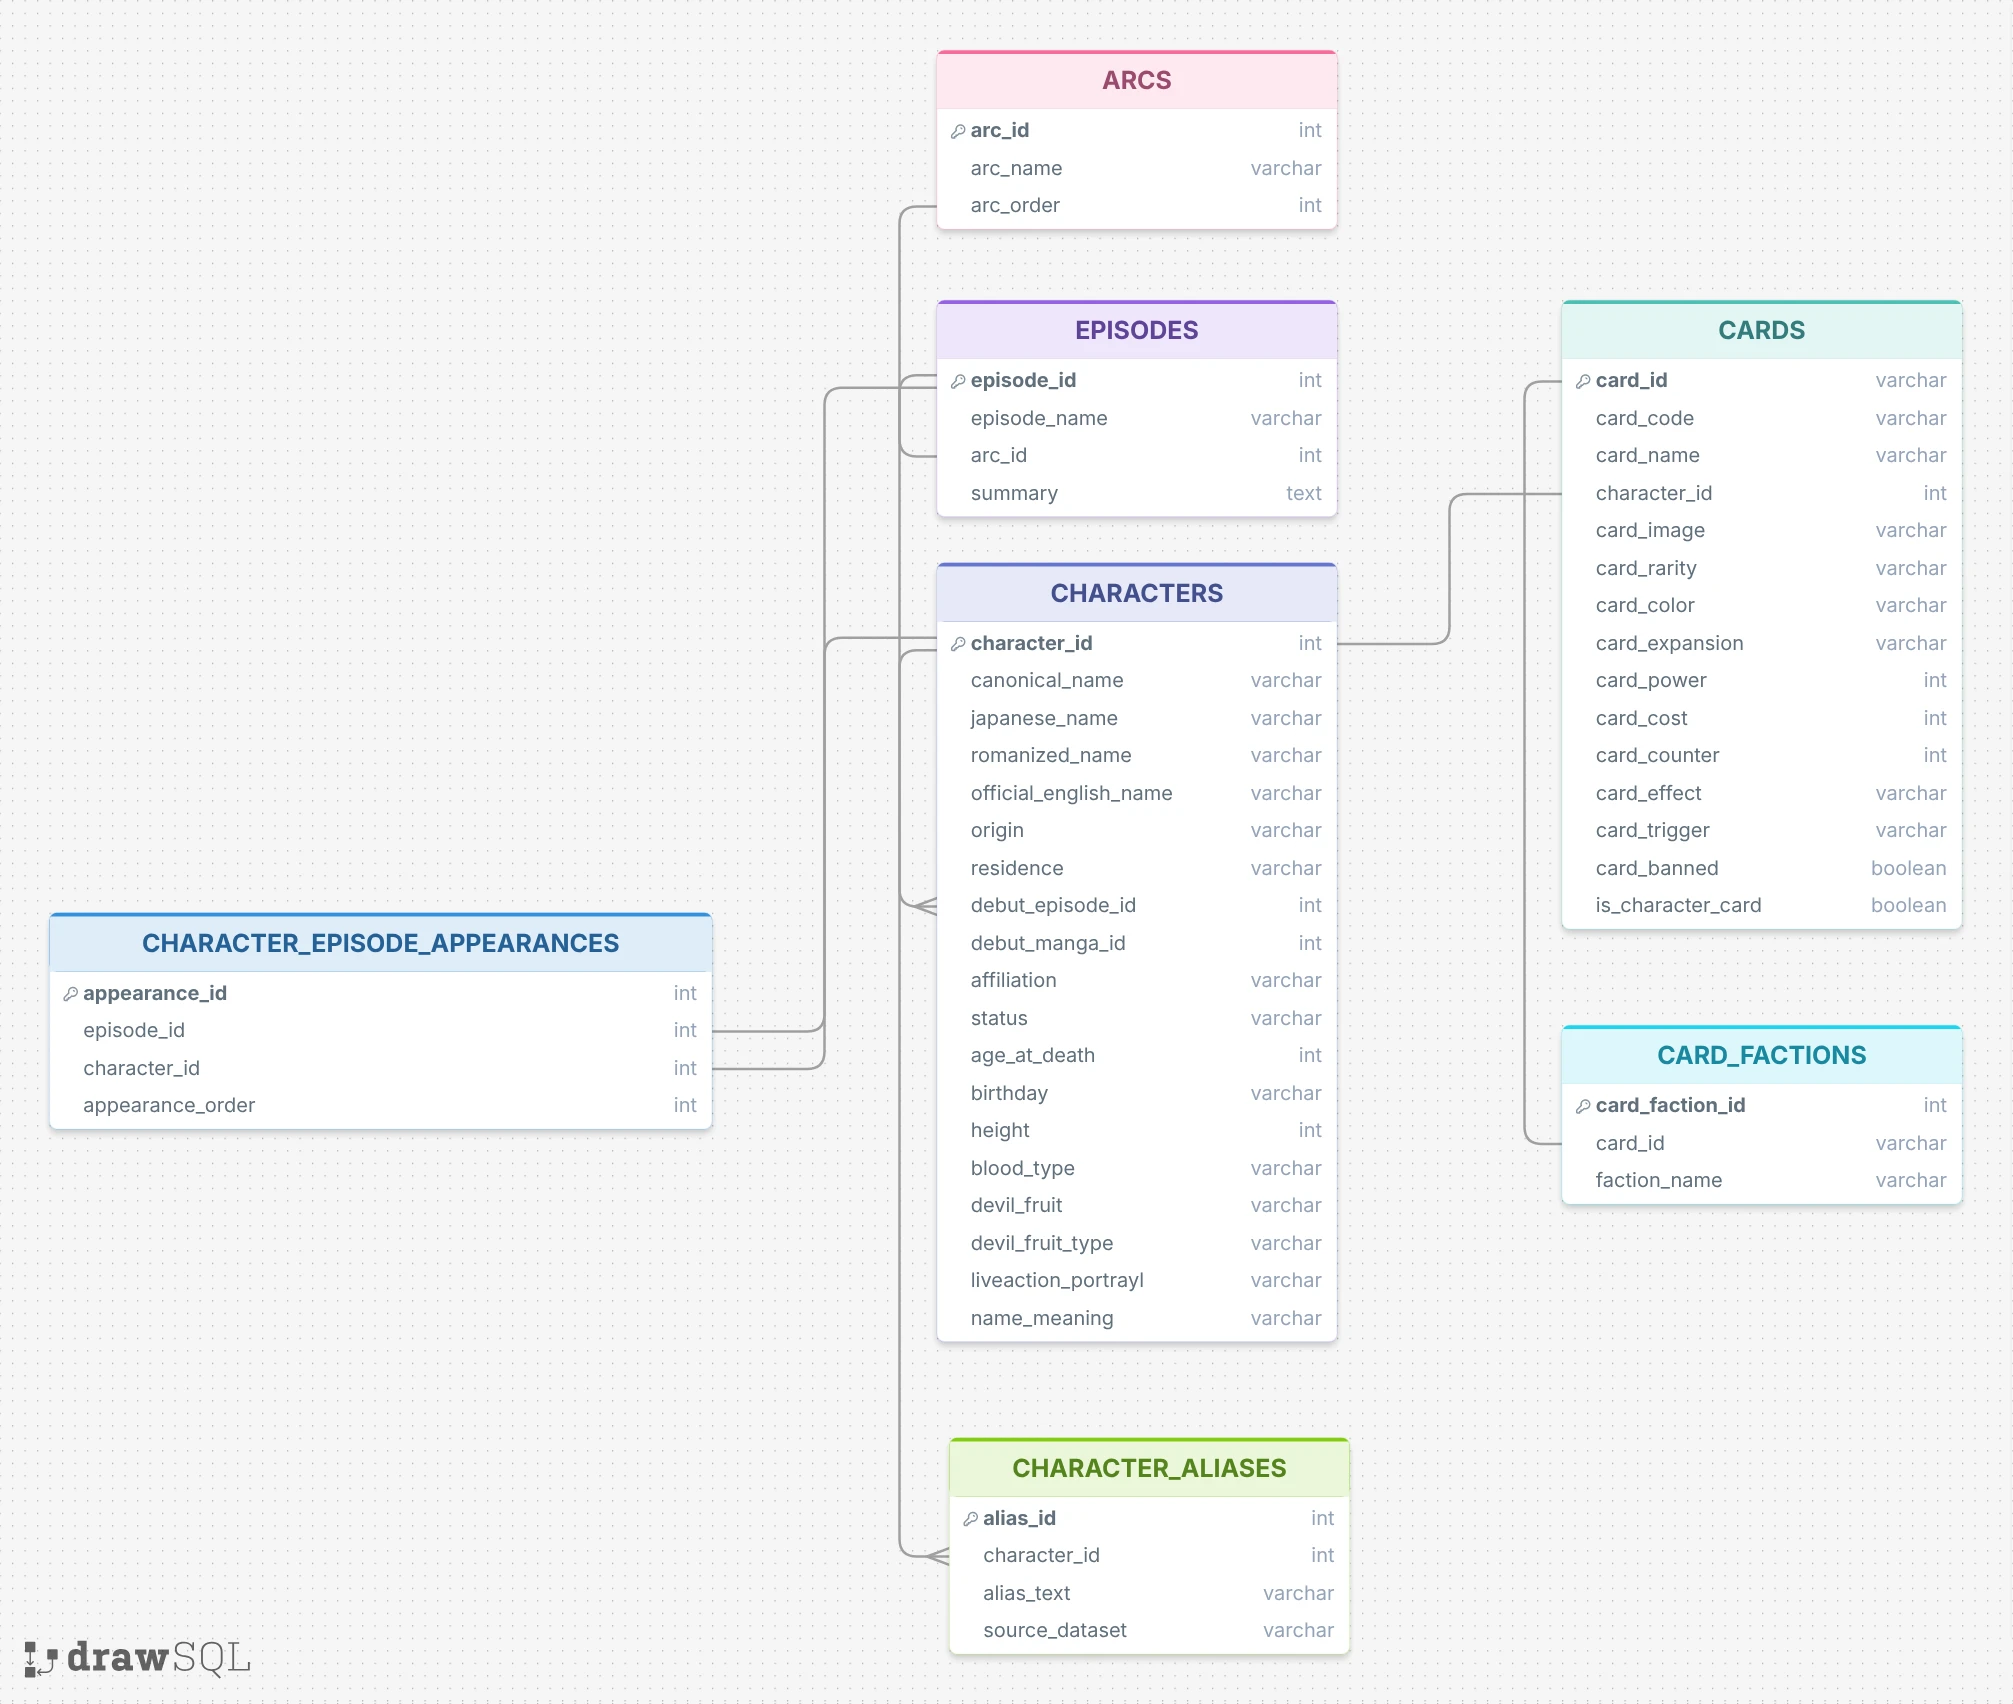

# Load

## Define helper functions

For this project, I loaded to the Postgres RDB on Aiven and using the service URI from the Aiven console for this project as it is free. Feel free to do what you would like.

For this project I decided to take a different approach when loading the tables. By using the `load_table()` function that uses `psycopg2.extras.execute_values()` instead `cur.executemany()` I am able to load the database much faster. `executemany()` worked but it was exteremly slow on my computer so I looked into different methods of inserting data into the database.

`pyscog2.extras.execute_values()` sends every row in a single batched statement instead which helped improve the loadtime signfigantly. This also ended up being more effiecent as creating the `load_table()` helper function afterwords saved me from a lot of copy and pasting code.

In [ ]:
import os
import psycopg2
import psycopg2.extras
from dotenv import load_dotenv

load_dotenv()  # reads DATABASE_URL from a local .env file (see .env.example)
rdb_uri = os.environ["DATABASE_URL"]

def get_conn_cur():
    conn = psycopg2.connect(rdb_uri)
    cur = conn.cursor()
    return (conn, cur)

def get_table_names():
  conn, cur = get_conn_cur()
  table_name_query = """SELECT table_name FROM information_schema.tables
       WHERE table_schema = 'public' """
  cur.execute(table_name_query)
  my_data = cur.fetchall()
  cur.close()
  conn.close()

  return(my_data)

def my_drop_table(tab_name):
  conn, cur = get_conn_cur()
  tq = """DROP TABLE IF EXISTS %s CASCADE;""" %tab_name
  cur.execute(tq)
  conn.commit()

def run_query(query_string):
    conn, cur = get_conn_cur()
    cur.execute(query_string)
    colnames = [desc[0] for desc in cur.description]
    my_data = cur.fetchall()
    cur.close()
    conn.close()
    return (colnames, my_data)

def load_table(table_name, create_sql, load_df):
  my_drop_table(table_name)
  conn, cur = get_conn_cur()
  cur.execute(create_sql)
  conn.commit()
  tups = [tuple(x) for x in load_df.to_numpy()]
  iq = f"INSERT INTO {table_name}(" + ','.join(load_df.columns) + ") VALUES %s"
  psycopg2.extras.execute_values(cur, iq, tups)
  conn.commit()
  cur.close()
  conn.close()

## Preperation for Loading

To prepare for loading, preparing each data file is important for the load_table function. This includes prepping for NA handling. For each column that is supposed to hold whole number but might have missing values such as `age_at_death` , change the type to `.astype('Int64')` . Then an extra saftey layer is done with `.fillna(np.nan).replace([np.nan]), [None]` to prep for NA values.

In [ ]:
arcs_load = arcs.copy()
arcs_load = arcs_load.fillna(np.nan).replace({np.nan: None})

episodes_load = episodes.copy()
episodes_load['arc_id'] = episodes_load['arc_id'].astype('Int64')
episodes_load = episodes_load.fillna(np.nan).replace({np.nan: None})

characters_load = characters_final.copy()
characters_load['debut_episodes_id'] = characters_load['debut_episodes_id'].astype('Int64')
characters_load['debut_manga_id'] = characters_load['debut_manga_id'].astype('Int64')
characters_load['age_at_death'] = characters_load['age_at_death'].astype('Int64')
characters_load['height_cm'] = characters_load['height_cm'].astype('Int64')
characters_load = characters_load.fillna(np.nan).replace({np.nan: None})

aliases_load = character_aliases[['alias_id', 'character_id', 'alias_text', 'source_dataset']].copy()
aliases_load = aliases_load.fillna(np.nan).replace({np.nan: None})

appearances_load = character_episode_appearances.copy()
appearances_load['character_id'] = appearances_load['character_id'].astype('Int64')
appearances_load = appearances_load.fillna(np.nan).replace({np.nan: None})

cards_load = cards_final.copy()
cards_load['character_id'] = cards_load['character_id'].astype('Int64')
cards_load['card_banned'] = cards_load['card_banned'].astype(bool)
cards_load = cards_load.fillna(np.nan).replace({np.nan: None})

cards_factions_load = card_factions.copy()
cards_factions_load = cards_factions_load.fillna(np.nan).replace({np.nan: None})

## Load ARCS

In [ ]:
load_table('arcs', """CREATE TABLE arcs(
  arc_id INTEGER PRIMARY KEY,
  arc_name VARCHAR(255) NOT NULL,
  arc_order INTEGER
  );""", arcs_load)

## Load EPISODES

In [ ]:
load_table('episodes', """CREATE TABLE episodes (
  episode_id INTEGER PRIMARY KEY,
  episode_name VARCHAR(500),
  arc_id INTEGER REFERENCES arcs(arc_id),
  summary TEXT
  );""", episodes_load)

## Load CHARACTERS

In [ ]:
load_table('characters', """CREATE TABLE characters (
  character_id INTEGER PRIMARY KEY,
  canonical_name VARCHAR(255) NOT NULL,
  japanese_name VARCHAR(255),
  romanized_name VARCHAR(255),
  official_english_name VARCHAR(500),
  origin VARCHAR(255),
  residence VARCHAR(255),
  debut_episodes_id INTEGER REFERENCES episodes(episode_id),
  debut_manga_id INTEGER,
  affiliations VARCHAR(255),
  status VARCHAR(100),
  age_at_death INTEGER,
  height_cm INTEGER,
  blood_type VARCHAR(100),
  devil_fruit VARCHAR(225),
  devil_fruit_type VARCHAR(225),
  birthday VARCHAR(100),
  liveaction_portrayal VARCHAR(255),
  name_meaning VARCHAR(225)
  );""", characters_load)

## Load CHARACTER_ALIASES

In [ ]:
load_table('character_aliases', """CREATE TABLE character_aliases (
  alias_id INTEGER PRIMARY KEY,
  character_id INTEGER REFERENCES characters(character_id),
  alias_text VARCHAR(500),
  source_dataset VARCHAR(225)
  );""", aliases_load)

## Load CHARACTER_EPISODE_APPEARANCES

In [ ]:
load_table('character_episode_appearances', """CREATE TABLE character_episode_appearances (
  appearance_id INTEGER PRIMARY KEY,
  episode_id INTEGER REFERENCES episodes(episode_id),
  character_id INTEGER REFERENCES characters(character_id),
  appearance_order INTEGER
  );""", appearances_load)

## Load CARDS

In [ ]:
load_table('cards', """CREATE TABLE cards (
  card_id VARCHAR(50) PRIMARY KEY,
  card_code VARCHAR(50),
  card_art_variant INTEGER,
  card_name VARCHAR(225),
  character_id INTEGER REFERENCES characters(character_id),
  card_rarity VARCHAR(50),
  card_color VARCHAR(50),
  card_expansion VARCHAR(50),
  card_power INTEGER,
  card_cost INTEGER,
  card_counter INTEGER,
  card_effect TEXT,
  card_trigger TEXT,
  card_image VARCHAR(255),
  card_type VARCHAR(50),
  card_banned BOOLEAN,
  is_character_card BOOLEAN
  );""", cards_load)

## Load CARD_FACTIONS

In [ ]:
load_table('card_factions', """CREATE TABLE card_factions (
  card_faction_id INTEGER PRIMARY KEY,
  card_id VARCHAR(50) REFERENCES cards(card_id),
  faction_name VARCHAR(225)
  );""", cards_factions_load)

In [ ]:
# Shares table information with HW5 & Other Class Work

get_table_names()

[('arc',),
 ('arcs',),
 ('battle_data',),
 ('card_factions',),
 ('cards',),
 ('cases',),
 ('casetype',),
 ('character_aliases',),
 ('character_episode_appearances',),
 ('characters',),
 ('episodes',),
 ('house_information',),
 ('judges',),
 ('regional_information',),
 ('rollup',),
 ('states',),
 ('weekly_stats',)]

# Check It / Queries

Let's run a few basic verification queries to confirm that all of the data is correct then complex queries to confirm the data has been loaded correctly. I'd like to answer a few of the research questions that were illustrated at the top of this notebook as well.

## Verification Queries

Three simple queries to verify data before getting into the complex queries.

In [ ]:
# Find Monkey D. Luffy in the characters table

run_query("""
SELECT *
FROM characters
WHERE canonical_name = 'Monkey D. Luffy'
""")

(['character_id',
  'canonical_name',
  'japanese_name',
  'romanized_name',
  'official_english_name',
  'origin',
  'residence',
  'debut_episodes_id',
  'debut_manga_id',
  'affiliations',
  'status',
  'age_at_death',
  'height_cm',
  'blood_type',
  'devil_fruit',
  'devil_fruit_type',
  'birthday',
  'liveaction_portrayal',
  'name_meaning'],
 [(558,
   'Monkey D. Luffy',
   'Gomu Gomu no Mi(Hito Hito no Mi, Model: Nika)',
   'Monkī Dī Rufi',
   'Monkey D. Luffy',
   'East Blue (Goa Kingdom)',
   'Foosha Village (former);Mt. Colubo (former);Rusukaina (former)',
   1,
   1,
   'Straw Hat Pirates;Straw Hat Grand Fleet;Four Emperors;Dadan Family (former);Baratie (temporary, former);Impel Down (former);Ninja-Pirate-Mink-Samurai Alliance (disbanded)',
   'Alive',
   None,
   91,
   'F',
   'Gum-Gum Fruit',
   'Paramecia(Mythical Zoan)',
   "May 5th (Children's Day)",
   'Iñaki Godoy;Colton Osorio (young)',
   'Rubber; Human; Nika')])

In [ ]:
# Confirm that episode_id and arc_id are linked properly

run_query("""
SELECT episodes.episode_id, episodes.episode_name, arcs.arc_name
FROM episodes
JOIN arcs ON arcs.arc_id = episodes.arc_id
WHERE episodes.episode_id = 1;
""")

(['episode_id', 'episode_name', 'arc_name'],
 [(1,
   "I'm Luffy! The Man Who Will Become the Pirate King!",
   'Romance Dawn Arc')])

In [ ]:
# Check the this specific card_id, should be Marshall D. Teach

run_query("""
SELECT *
FROM cards
WHERE card_id = 'OP09-092-0'
""")

(['card_id',
  'card_code',
  'card_art_variant',
  'card_name',
  'character_id',
  'card_rarity',
  'card_color',
  'card_expansion',
  'card_power',
  'card_cost',
  'card_counter',
  'card_effect',
  'card_trigger',
  'card_image',
  'card_type',
  'card_banned',
  'is_character_card'],
 [('OP09-092-0',
   'OP09-092',
   0,
   'Marshall.D.Teach',
   623,
   'C',
   'Black',
   'OP09',
   4000,
   3,
   1000,
   "[Activate: Main] You may rest this Character: If the number of cards in your hand is at least 3 less than the number in your opponent's hand, draw 2 cards and trash 1 card from your hand.",
   None,
   'https://en.onepiece-cardgame.com/images/cardlist/card/OP09-092.png?250502',
   None,
   False,
   True)])

## Complex Queries

### **How many cards does each character have?**
- this is a question I find personally interesting and will test if the data has loaded correctly as a whole. This is also a pretty easy sample question that the target audience may be interested in.

In [ ]:
run_query("""
SELECT ch.canonical_name, COUNT(*) AS card_count
FROM cards AS c
JOIN characters AS ch on ch.character_id = c.character_id
GROUP BY ch.character_id
ORDER BY card_count DESC
LIMIT 50
;""")

(['canonical_name', 'card_count'],
 [('Monkey D. Luffy', 120),
  ('Sanji', 54),
  ('Nami', 52),
  ('Trafalgar D. Water Law', 50),
  ('Roronoa Zoro', 47),
  ('Tony Tony Chopper', 40),
  ('Portgas D. Ace', 36),
  ('Nico Robin', 34),
  ('Usopp', 32),
  ('Sabo', 30),
  ('Jimbei', 29),
  ('Uta', 28),
  ('Esta', 28),
  ('Shanks', 27),
  ('Boa Hancock', 25),
  ('Charlotte Pudding', 24),
  ('Kaido', 24),
  ('Brook', 23),
  ('Jewelry Bonney', 23),
  ('Yamato', 23),
  ('Franky', 23),
  ('Crocodile', 22),
  ('Don Quixote Doflamingo', 21),
  ('Don Quixote Rocinante', 20),
  ('Dracule Mihawk', 20),
  ('Shirahoshi', 19),
  ('Perona', 18),
  ('Edward Newgate', 18),
  ('Monkey D. Garp', 18),
  ('Kuzan', 18),
  ('Buggy', 17),
  ('Marco', 17),
  ('Charlotte Katakuri', 17),
  ('Rob Lucci', 16),
  ('Koby', 15),
  ('Emporio Ivankov', 15),
  ('Tashigi', 15),
  ('Vinsmoke Reiju', 15),
  ('Izo', 14),
  ('Cancer', 14),
  ('Gecko Moria', 14),
  ('Charlotte Linlin', 14),
  ('Marshall D. Teech', 14),
  ('Nefeltar

### **Does a character's debut arc predict how many cards they will have?**
- This query answers the debut research question posed at the beginning of the notebook. Instead of the question answering at a personal level for each character this way it will resolve the question at the arc level.

In [ ]:
run_query("""
SELECT a.arc_name AS arc_name, a.arc_order AS arc_order, COUNT(DISTINCT c.character_id) AS character_debuted, COUNT(ca.card_id) AS total_card_count
FROM arcs AS a
JOIN episodes AS e ON e.arc_id = a.arc_id
JOIN characters AS c ON c.debut_episodes_id = e.episode_id
LEFT JOIN cards as ca ON ca.character_id = c.character_id AND ca.is_character_card = TRUE
GROUP BY a.arc_name, a.arc_order
ORDER BY arc_order
""")


(['arc_name', 'arc_order', 'character_debuted', 'total_card_count'],
 [('Romance Dawn Arc', 1, 18, 259),
  ('Orange Town Arc', 2, 23, 109),
  ('Syrup Village Arc', 3, 19, 21),
  ('Baratie Arc', 4, 17, 95),
  ('Arlong Park Arc', 5, 19, 25),
  ('Loguetown Arc', 6, 14, 49),
  ('Reverse Mountain Arc', 9, 7, 20),
  ('Whisky Peak Arc', 10, 10, 39),
  ('Diary of Koby and Helmeppo Arc', 11, 2, 19),
  ('Little Garden Arc', 12, 7, 23),
  ('Drum Island Arc', 13, 27, 96),
  ('Arabasta Arc', 14, 34, 31),
  ('Jaya Arc', 19, 40, 115),
  ('Skypiea Arc', 20, 44, 50),
  ('Long Ring Long Land Arc', 22, 15, 16),
  ('Foxy’s Return Arc', 24, 1, 18),
  ('Water 7 Arc', 25, 41, 76),
  ('Enies Lobby Arc', 26, 35, 38),
  ('Post-Enies Lobby Arc', 29, 5, 10),
  ('Thriller Bark Arc', 32, 34, 76),
  ('Sabaody Archipelago Arc', 34, 43, 157),
  ('Amazon Lily Arc', 36, 24, 35),
  ('Straw Hat’s Separation Serial Arc', 37, 11, 5),
  ('Impel Down Arc', 38, 32, 78),
  ('Little East Blue Arc', 39, 1, 0),
  ('Marineford Arc'

### **Does having more episode appearances mean getting rarer (SEC) cards?**

- The query connects back to the research question about rarity and why some characters may have more rare cards then others. This question challenges prominence in the show vs. prominence in the card game and tracks each other in an interesting way.


In [ ]:
run_query("""
SELECT c.canonical_name AS canonical_name,
      COUNT(DISTINCT ca.card_id) FILTER (WHERE ca.card_rarity = 'SEC') AS sec_card_count,
      COUNT(DISTINCT cea.episode_id) AS episode_appearances
FROM characters AS c
LEFT JOIN cards AS ca ON ca.character_id = c.character_id
LEFT JOIN character_episode_appearances AS cea ON cea.character_id = c.character_id
GROUP BY c.character_id, c.canonical_name
HAVING COUNT(DISTINCT ca.card_id) FILTER (WHERE ca.card_rarity = 'SEC') > 0
ORDER BY sec_card_count DESC;
""")

(['canonical_name', 'sec_card_count', 'episode_appearances'],
 [('Monkey D. Luffy', 15, 1075),
  ('Shanks', 5, 78),
  ('Roronoa Zoro', 4, 797),
  ('Charlotte Katakuri', 4, 49),
  ('Silvers Rayleigh', 3, 66),
  ('Yamato', 3, 68),
  ('Uta', 3, 3),
  ('Portgas D. Ace', 3, 140),
  ('Usopp', 3, 751),
  ('Kuzan', 3, 26),
  ('Kaido', 3, 156),
  ('Koby', 3, 54),
  ('Jewelry Bonney', 3, 47),
  ('Gol D. Roger', 3, 54),
  ('Trafalgar D. Water Law', 3, 269),
  ('Bartholomew Kuma', 2, 85),
  ('Sanji', 2, 766),
  ('Sabo', 2, 65),
  ('Nefeltari Vivi', 2, 105),
  ('Don Quixote Rocinante', 2, 19),
  ('Bentham', 2, 45)])